# Lesson 1 — Describing a real dataset

*Part 1 · Lesson 1 of 20  ·  data: Palmer Penguins*

**←** [Start here: How these notebooks work](00-how-these-notebooks-work.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  [Lesson 2: Distributions: shape, skew & outliers](02-distributions-shape-outliers.ipynb) **→**

**Same idea, another way:**  [Another dataset →](01-describing-data~another-dataset.ipynb)  ·  [The code behind it →](01-describing-data~the-code.ipynb)

**Welcome.** The most important habit in statistics is to *look at the data before doing anything fancy*. We'll use a real dataset — **344 penguins** measured at Palmer Station, Antarctica — and describe them on three levels at once:

- **The math** — the actual formula.
- **The meaning** — what the number *is* and what it *does*.
- **The interpretation** — what it *says* about these penguins.

Read it, run it, look at the picture, then **tinker** (change a number and re-run).

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sl.use_course_style()

PENGUINS_URL = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'
penguins = sl.load_csv('penguins.csv', url=PENGUINS_URL)

# Keep rows that have the measurements we'll use (a few are missing).
penguins = penguins.dropna(subset=['body_mass_g', 'flipper_length_mm', 'sex'])
print(f'{len(penguins)} penguins, {penguins.shape[1]} columns')
penguins.head()

333 penguins, 8 columns


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


## What kind of data is this?

Before any math, ask: *what is each column?* Statisticians sort variables by their **level of measurement**, because it decides which tools are allowed.

| Level | Meaning | Example here |
|---|---|---|
| **Nominal** | named categories, no order | `species`, `island`, `sex` |
| **Ordinal** | ordered categories, uneven gaps | (none here) |
| **Interval** | numbers, no true zero | `year` |
| **Ratio** | numbers with a true zero (0 = none) | `body_mass_g`, `flipper_length_mm` |

`body_mass_g` is **ratio** data — 0 grams really means "no mass," so it makes sense to say one penguin is *twice* as heavy as another. That's why averages and ratios are meaningful for it.

In [2]:
penguins.describe(include='all')

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
count,333,333,333.000000,333.000000,333.000000,333.000000,333,333.000000
unique,3,3,NaN,NaN,NaN,NaN,2,NaN
top,Adelie,Biscoe,NaN,NaN,NaN,NaN,male,NaN
freq,146,163,NaN,NaN,NaN,NaN,168,NaN
mean,NaN,NaN,43.992793,17.164865,200.966967,4207.057057,NaN,2008.042042
std,NaN,NaN,5.468668,1.969235,14.015765,805.215802,NaN,0.812944
min,NaN,NaN,32.100000,13.100000,172.000000,2700.000000,NaN,2007.000000
25%,NaN,NaN,39.500000,15.600000,190.000000,3550.000000,NaN,2007.000000
50%,NaN,NaN,44.500000,17.300000,197.000000,4050.000000,NaN,2008.000000
75%,NaN,NaN,48.600000,18.700000,213.000000,4775.000000,NaN,2009.000000


*You'll see **`NaN`** in some boxes above — it just means "not applicable here," e.g. you can't take an average of a word like a species name. It's normal, not an error.*

## 1) Measures of center — "what's typical?"

Three ways to answer "what's a typical value?":

- **Mean** (the average): $\displaystyle \bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$ — add them all up, divide by how many.
- **Median**: the middle value when sorted. Half below, half above.
- **Mode**: the most common value. Most natural for *categories*.

**Meaning:** the mean uses every value (so a few giants pull it up); the median just asks "who's in the middle?" (so extremes barely move it).

**Interpretation:** when the mean and median land close together (as they will for these penguins), "typical" is a trustworthy summary; when they drift apart, the data is lopsided and the mean becomes misleading — exactly the story of Lesson 2.

In [3]:
mass = penguins['body_mass_g']
print(f"Mean body mass:   {mass.mean():.1f} g")
print(f"Median body mass: {mass.median():.1f} g")
# Mode is most natural for a category:
print(f"Most common species (mode): {penguins['species'].mode()[0]}")

Mean body mass:   4207.1 g
Median body mass: 4050.0 g
Most common species (mode): Adelie


## 2) Measures of spread — "how varied are they?"

A typical value isn't enough — we need to know how *spread out* the penguins are.

- **Range** = max - min (simple, but only sees the two extremes).
- **Variance**: $\displaystyle s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})^2$ — the average *squared* distance from the mean.
- **Standard deviation**: $s=\sqrt{s^2}$ — back in the original units (grams), so it's readable.
- **IQR** (interquartile range) = 75th - 25th **percentile** — the width of the middle 50%, and it ignores outliers. (A *percentile* is the value a given share falls below: the 25th percentile is the mass a quarter of penguins weigh *less* than.)

**Meaning:** standard deviation is the everyday "give or take." A mean of ~4200 g with an SD of ~800 g means a typical penguin is *4200 g, give or take ~800 g.*

**Interpretation:** the SD tells you how *alike* the penguins are — a small SD means they huddle near the mean; a large one means they're spread all over. It turns a vague "give or take" into an actual number.

In [4]:
print(f"Range:    {mass.max() - mass.min():.0f} g")
print(f"Variance: {mass.var(ddof=1):,.0f} g^2   (squared units - hard to read)")
print(f"Std dev:  {mass.std(ddof=1):.1f} g   (the everyday 'give or take')")
q1, q3 = mass.quantile([0.25, 0.75])
print(f"IQR:      {q3 - q1:.0f} g   (width of the middle 50%)")

Range:    3600 g
Variance: 648,372 g^2   (squared units - hard to read)
Std dev:  805.2 g   (the everyday 'give or take')
IQR:      1225 g   (width of the middle 50%)


## 3) Shape — *picture* the whole distribution

Numbers summarize; a **histogram** shows the full story — where values cluster, whether it's symmetric or skewed, and whether there are outliers.

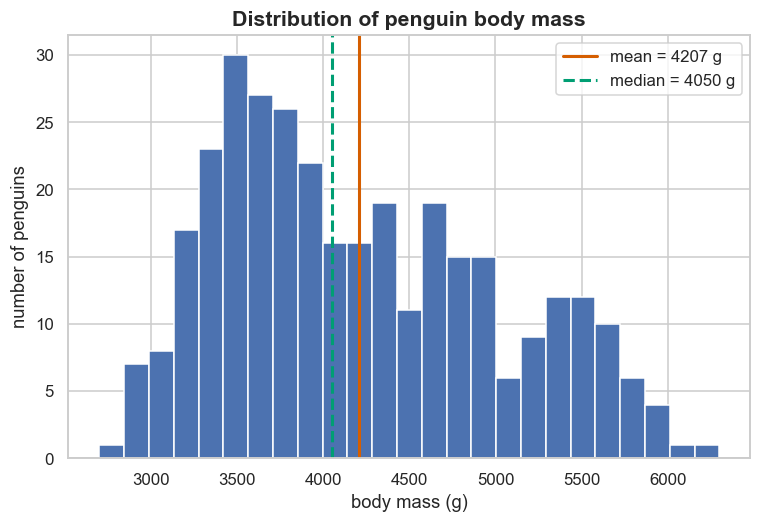

In [5]:
fig, ax = plt.subplots()
ax.hist(mass, bins=25, color='#4c72b0', edgecolor='white')
ax.axvline(mass.mean(), color='#D55E00', lw=2, label=f'mean = {mass.mean():.0f} g')
ax.axvline(mass.median(), color='#009E73', lw=2, ls='--', label=f'median = {mass.median():.0f} g')
ax.set_xlabel('body mass (g)'); ax.set_ylabel('number of penguins')
ax.set_title('Distribution of penguin body mass')
ax.legend(); plt.show()

### Comparing groups with a boxplot

A **boxplot** draws the median (middle line), the middle-50% box (the IQR), and flags outliers as dots. Splitting by species shows how the three kinds differ.

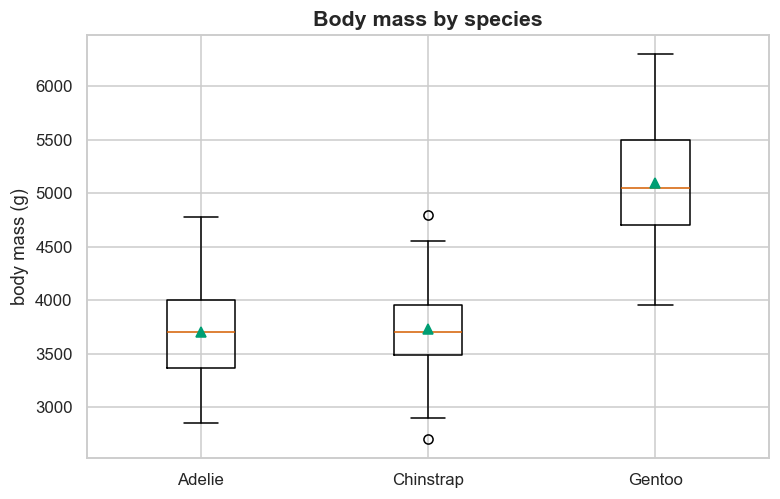

In [6]:
species_order = ['Adelie', 'Chinstrap', 'Gentoo']
groups = [penguins.loc[penguins['species'] == s, 'body_mass_g'] for s in species_order]
fig, ax = plt.subplots()
ax.boxplot(groups, tick_labels=species_order, showmeans=True)
ax.set_ylabel('body mass (g)'); ax.set_title('Body mass by species')
plt.show()

## 4) Relationships — do two measurements move together?

A **scatterplot** plots two numbers against each other. **Correlation** ($r$, between -1 and +1) summarizes the straight-line trend: +1 perfectly up, 0 no linear trend, -1 perfectly down.

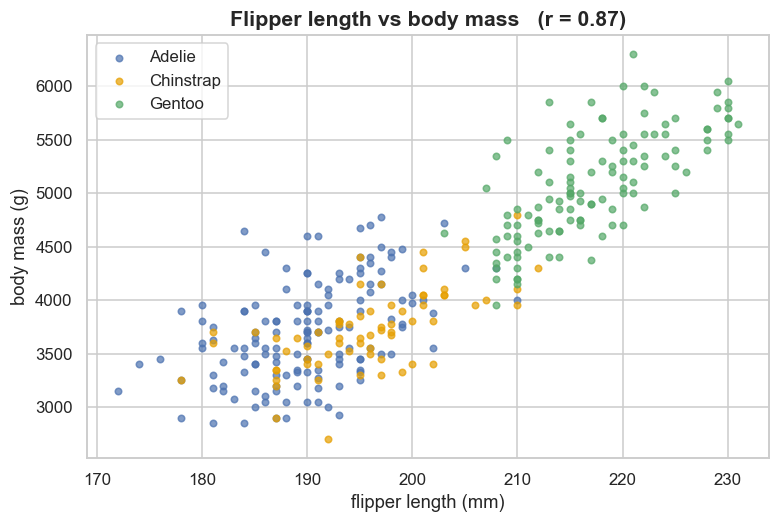

Correlation r = 0.873  ->  longer flippers strongly go with heavier penguins.


In [7]:
r = penguins['flipper_length_mm'].corr(penguins['body_mass_g'])
colors = {'Adelie': '#4c72b0', 'Chinstrap': '#E69F00', 'Gentoo': '#55a868'}
fig, ax = plt.subplots()
for s in species_order:
    sub = penguins[penguins['species'] == s]
    ax.scatter(sub['flipper_length_mm'], sub['body_mass_g'], s=18, alpha=0.7, label=s, color=colors[s])
ax.set_xlabel('flipper length (mm)'); ax.set_ylabel('body mass (g)')
ax.set_title(f'Flipper length vs body mass   (r = {r:.2f})')
ax.legend(); plt.show()
print(f'Correlation r = {r:.3f}  ->  longer flippers strongly go with heavier penguins.')

## 5) z-scores — "how unusual is one penguin?"

A **z-score** rescales a value into "how many standard deviations from the mean":

$$z = \frac{x - \bar{x}}{s}$$

$z = 0$ is exactly average; $z = +2$ means "2 SDs above the mean" (heavy); $z = -1.5$ means "1.5 SDs below" (light). It lets you compare values measured on different scales.

In [8]:
penguins = penguins.assign(mass_z=(mass - mass.mean()) / mass.std(ddof=1))
within1 = (penguins['mass_z'].abs() < 1).mean() * 100
print(f"{within1:.0f}% of penguins are within 1 SD of the mean mass.")
heaviest = penguins.loc[penguins['mass_z'].idxmax()]
print(f"Heaviest penguin: {heaviest['body_mass_g']:.0f} g  (z = {heaviest['mass_z']:.2f}, a {heaviest['species']}).")

65% of penguins are within 1 SD of the mean mass.
Heaviest penguin: 6300 g  (z = 2.60, a Gentoo).


## Now you try

Change something and re-run the cells above:

1. Swap `body_mass_g` for `flipper_length_mm` or `bill_length_mm` in the center/spread cells. Does the shape change?
2. In the histogram, change `bins=25` to `bins=10` or `bins=60`. How does the story change?
3. **Describe just one species.** Add a new cell (the **+** button in the toolbar above), type these two lines, and run them with Shift+Enter:

       gentoo = penguins[penguins['species'] == 'Gentoo']
       gentoo['body_mass_g'].mean()

   How does the Gentoo average compare to the all-penguins average you found earlier?

## What you learned

- **Center** (mean/median/mode), **spread** (SD/IQR/range), and **shape** (histogram) are the first three questions for *any* dataset.
- The **mean** is pulled by outliers; the **median** resists them.
- **z-scores** put any value on a common "SDs from the mean" ruler.
- A picture (**histogram**, **boxplot**, **scatter**) often reveals what a single number hides.

**Next:** Lesson 2 digs into *distributions* — the **shape** of data, **skew**, **outliers**, and the moment when a single summary number quietly lies.

---

**← Previous:** [Start here: How these notebooks work](00-how-these-notebooks-work.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Next →:** [Lesson 2: Distributions: shape, skew & outliers](02-distributions-shape-outliers.ipynb)

**Same idea, another way:**  [Another dataset →](01-describing-data~another-dataset.ipynb)  ·  [The code behind it →](01-describing-data~the-code.ipynb)